In [4]:
pip install qfin 

Note: you may need to restart the kernel to use updated packages.


In [111]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.stats import norm



### Geometric Brownian Motion (GBM)
We will use a GBM-based Monte Carlo simulation to simulate Nvidia's option strike price under both realized volatility ("market's fair price") and implied volatility backed out by the Black-Scholes Model.

A general Geometric Brownian Motion equation is as follows:

$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

| Symbol        | Description                        |
|---------------|------------------------------------|
| $S_t$         | Asset price at time $t$            |
| $S_0$         | Initial asset price                |
| $\mu$         | Drift (expected return)            |
| $\sigma$      | Volatility                         |
| $t$           | Time horizon                       |
| $\Delta t$    | Time step                          |
| $dW_t$        | Wiener process increment           |
| $Z, \varepsilon$ | Standard normal random variable |


In [ ]:
import math 
class StochasticProcess:
    def __init__(self, asset_price, drift, delta_t, vol):
        self.currentt_asset_price = asset_price
        self.asset_price = [asset_price]    
        self.drift = drift
        self.delta_t = delta_t
        self.vol = vol

    def time_step (self):
        dw = np.random.normal(0, math.sqrt(self.delta_t)) #Generates random shock for the Monte Carlo simulation
        dS = self.drift * self.currentt_asset_price * self.delta_t + self.vol * self.currentt_asset_price * dw

        self.currentt_asset_price += dS
        self.asset_price.append(self.currentt_asset_price)  

In [ ]:
class EuroCall:
    def __init__(self, strike):
        self.strike = strike

In [115]:
class EuroCallSimulation: 
    def __init__(self, EuroCall, n_options, current_asset_price, drift, delta_t, vol, time_to_exp, risk_free_rate):
        # Initialize stochastic processes for each option
        stochastic_processes = [
            StochasticProcess(current_asset_price, drift, delta_t, vol)
            for _ in range(n_options)
        ]
        self.stochastic_processes = stochastic_processes

        # Simulate the stochastic process for each option
        for stochastic_process in stochastic_processes:
            tte = time_to_exp
            while tte > stochastic_process.delta_t:
                tte -= stochastic_process.delta_t
                stochastic_process.time_step()

        # Calculate payoffs for each option
        payoffs = []
        for stochastic_process in stochastic_processes:
            final_price = stochastic_process.asset_price[-1]
            payoff = max(0, final_price - EuroCall.strike)  # Call option logic
            payoffs.append(payoff)
        
        # Calculate the option price
        self.price = np.mean(payoffs) * math.exp(-time_to_exp * risk_free_rate)


# Example usage
sim = EuroCallSimulation(EuroCall(170), 10000, 178.10, 0.036, 1/365, 0.264, 6/365, 0.036)
print('Monte Carlo Simulation Price: ', sim.price)

Monte Carlo Simulation Price:  8.449998832498668


In [109]:
class EuroCallSimulation: 
    def __init__(self, EuroCall, n_options, current_asset_price, drift, delta_t, vol, time_to_exp, risk_free_rate):
        # Initialize stochastic processes for each option
        stochastic_processes = [
            StochasticProcess(current_asset_price, drift, delta_t, vol)
            for _ in range(n_options)
        ]
        self.stochastic_processes = stochastic_processes

        # Simulate the stochastic process for each option
        for stochastic_process in stochastic_processes:
            tte = time_to_exp
            while tte > stochastic_process.delta_t:
                tte -= stochastic_process.delta_t
                stochastic_process.time_step()

        # Calculate payoffs for each option
        payoffs = []
        for stochastic_process in stochastic_processes:
            final_price = stochastic_process.asset_price[-1]
            payoff = max(0, final_price - EuroCall.strike)  # Call option logic
            payoffs.append(payoff)
        
        # Calculate the option price
        self.price = np.mean(payoffs) * math.exp(-time_to_exp * risk_free_rate)


# Example usage
sim = EuroCallSimulation(EuroCall(170), 10000, 178.10, 0.036, 1/(365*24), 0.4029, 6/365, 0.036)
print('Monte Carlo Simulation Price: ', sim.price)

Monte Carlo Simulation Price:  8.989735594789273


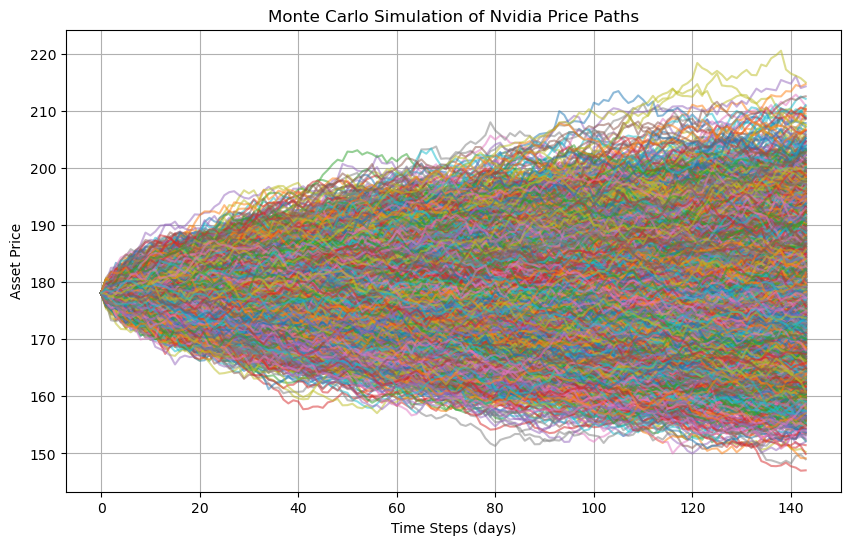

In [110]:
plt.figure(figsize=(10, 6))
for stochastic_process in sim.stochastic_processes:
    plt.plot(stochastic_process.asset_price, alpha=0.5)
plt.xlabel('Time Steps (days)')
plt.ylabel('Asset Price')   
plt.title('Monte Carlo Simulation of Nvidia Price Paths')
plt.grid()
plt.show()

The plot above shows 50,000 Monte Carlo simulated price paths for NVIDIA call options. Because each simulation draws from a random process, the estimated price varies slightly between runs. Notably, the theoretical value derived from NVIDIA's realized volatility diverges from the value calculated using implied volatility — evidence of the volatility risk premium. We can further illustrate this gap by reverse-engineering implied volatility through the Black-Scholes model

### Black Scholes Model 
Solving the Black Scholes Partial Differential Equation result in: 

$$ C(S,t) = S_t \phi (d_1) - e^{-r(T-t)} K \phi (d_2) $$

$$ d_1 = \frac{ln {(\frac {S_t}{K}) + (r + \sigma^2 / 2) (T-t)}}{\sigma \sqrt{T-t}} $$

$$ d_2 = d_1 - \sigma \sqrt{T-t} $$

## Continue...

 

In [113]:
def black_scholes_call_price(S, K, T, r, sigma):
    d1 = (math.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    
    call_price = S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)
    return call_price

In [116]:
from scipy.optimize import brentq
S = 178.10  # Spot price
K = 170      # Strike price
T = 6/365    # Time to expiry
r = 0.036    # Risk-free rate
sigma = 0.4  # Arbitrary Guess for Implied Volatility
C = 8.93  # Market price of the call option

imiplied_vol = brentq(lambda x: black_scholes_call_price(S, K, T, r, x) - C, 1e-4, 5)
print('Implied Volatility: ', imiplied_vol)

Implied Volatility:  0.37615970612127836


In [118]:
print('Black-Scholes Call Price: ', black_scholes_call_price(S, K, T, r, imiplied_vol))

Black-Scholes Call Price:  8.930000000000035


### Constructing The Volatility Surface 

The implied vol surface is simply the volatility needed to create equalibrium price under the assumption of the Black Scholes Framework. 

In [123]:
from datetime import datetime, timedelta

In [138]:
df = pd.read_csv('Nvidia Call Option Chain.csv')
df['mid'] = (df['Bid'] + df['Ask']) / 2

#time to expiration
today = datetime.now()
df['Expiration'] = df['Expiration'].astype(str)  # Ensure Expiration is a string
df['T'] = df['Expiration'].apply(lambda x: (datetime.strptime(x, '%m/%d/%Y') - today).days / 365)

df = df[df['T'] > 0]  # Filter out expired options
S = 178.10  # Current stock price
r = 0.036    # Risk-free rate

def implied_vol(S, K, T, r, C):
    try:
        return brentq(lambda sigma: black_scholes_call_price(S, K, T, r, sigma) - C, 1e-4, 5)
    except ValueError:
        return np.nan  # Return NaN if no solution is found
    
df['IV'] = df.apply(lambda row: implied_vol(S, row['Strike'], row['T'], r, row['mid']), axis=1)
df = df.dropna(subset=['IV'])  # Drop rows where IV could not be calculated
x = df['IV'].quantile(0.95)
y = df['IV'].quantile(0.05) 
df = df[(df['IV'] <= x) & (df['IV'] >= y)]  # Filter out outliers based on IV quantiles

In [158]:
import plotly.graph_objects as go
fig = go.Figure(data=go.Mesh3d(x=df['Strike'], y=df['T'], z=df['IV'], colorscale='Plasma', intensity=df['IV'], opacity=0.85))

fig.update_layout(title = 'Implied Volatility Surface for Nvidia Call Options', scene=dict(
                    xaxis_title='Strike Price',
                    yaxis_title='Time to Expiration (Years)',
                    zaxis_title='Implied Volatility',
                    bgcolor='white'),
                    width = 800, height = 650)
fig.show()